# 한국 영화는 어떻게 만들어지는가

ESAA YB 미니 프로젝트(1) — YB 2조

DACON 「영화 관객수 예측」 데이터(2010~2015년 개봉 한국 영화 600편)를 사용한다.
대회의 목표 변수는 관객수지만, 이번 과제의 목표는 **의미 있는 시각화와 결과 도출**이므로
관객수를 결과의 하나로만 두고 **"영화가 어떤 방식으로 만들어지는가"** 를 중심으로 살펴본다.

EDA에서 확인한 바로는 이 데이터에서 가장 강한 관계가 관객수와 무관한 곳
(상영시간 × 스태프 수, 상관 0.623)에 있었기 때문이다.

**구성**

| 부 | 질문 | 그래프 |
|---|---|---|
| 1부 | 장르가 제작 방식을 정하는가 | 1 ~ 5 |
| 2부 | 누가 어떤 영화를 맡는가 | 6 ~ 8 |
| 3부 | 언제 어떤 영화가 나오는가 | 9 ~ 10 |
| 4부 | 그래서 결과는 어땠는가 | 11 ~ 13 |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# seaborn 스타일이 폰트를 덮어쓰므로 set_style 뒤에 한글 폰트를 지정한다
sns.set_style('whitegrid')
sns.set_palette('deep')
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

pd.set_option('display.max_columns', 30)

## 전처리

EDA에서 정한 방침대로 처리한다.

- `dir_prev_bfnum` 결측 330건은 모두 전작이 없는 감독(데뷔작)이므로 **0으로 대체**
- 개봉일에서 **연도·월** 추출
- 스태프 수를 **제작 규모** 3구간으로 (EDA에서 확인한 계단 지점 기준)
- 전작 0편이면 **신인 감독**
- 관객수는 치우침이 심하므로 **로그 변환**
- 편수 20편 미만 장르(SF·미스터리·뮤지컬·서스펜스)는 표본이 부족해 **주요 8개 장르**만 사용

In [2]:
df = pd.read_csv('data/movies_train.csv')

df['dir_prev_bfnum'] = df['dir_prev_bfnum'].fillna(0)
df['release_time'] = pd.to_datetime(df['release_time'])
df['연도'] = df['release_time'].dt.year
df['월'] = df['release_time'].dt.month

df['규모'] = pd.cut(df['num_staff'], [-1, 80, 250, 900],
                  labels=['소(~80명)', '중(81~250명)', '대(251명~)'])
df['감독'] = np.where(df['dir_prev_num'] == 0, '신인', '경력')
df['log관객수'] = np.log10(df['box_off_num'])

# 편수 20편 이상인 주요 장르만
주요장르 = df['genre'].value_counts()
주요장르 = 주요장르[주요장르 >= 20].index.tolist()
sub = df[df['genre'].isin(주요장르)].copy()

# 스태프 수 중앙값이 큰 순서로 장르를 정렬해 모든 그래프에서 같은 순서를 쓴다
장르순 = sub.groupby('genre')['num_staff'].median().sort_values(ascending=False).index.tolist()

print('전체 %d편 / 주요 8개 장르 %d편' % (len(df), len(sub)))
print('장르 순서(스태프 수 기준):', 장르순)

전체 600편 / 주요 8개 장르 563편
장르 순서(스태프 수 기준): ['액션', '느와르', '코미디', '공포', '드라마', '멜로/로맨스', '다큐멘터리', '애니메이션']


---
# 1부. 장르가 제작 방식을 정하는가

## 그래프 1. 장르 × 제작 규모

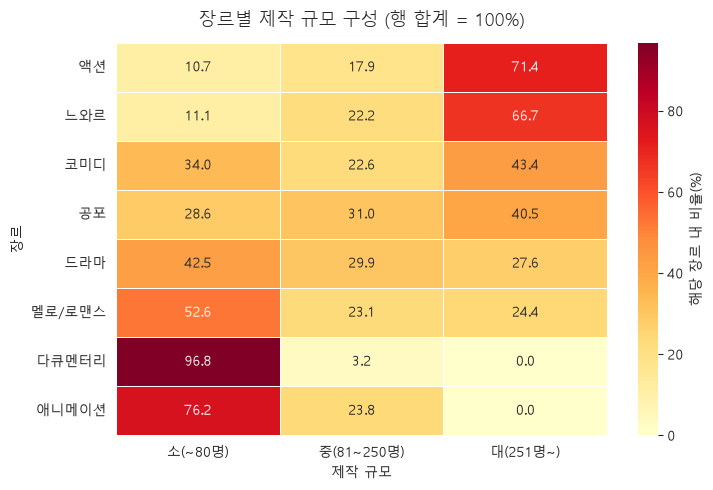

규모      소(~80명)  중(81~250명)  대(251명~)
genre                                
액션            3           5        20
느와르           3           6        18
코미디          18          12        23
공포           12          13        17
드라마          94          66        61
멜로/로맨스       41          18        19
다큐멘터리        90           3         0
애니메이션        16           5         0


In [3]:
비율 = pd.crosstab(sub['genre'], sub['규모'], normalize='index').loc[장르순] * 100

fig, ax = plt.subplots(figsize=(7.5, 5))
sns.heatmap(비율, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax,
            cbar_kws={'label': '해당 장르 내 비율(%)'}, linewidths=0.5)
ax.set_title('장르별 제작 규모 구성 (행 합계 = 100%)', fontsize=13, pad=12)
ax.set_xlabel('제작 규모')
ax.set_ylabel('장르')
plt.tight_layout()
plt.show()

print(pd.crosstab(sub['genre'], sub['규모']).loc[장르순])

**액션은 71.4%, 느와르는 66.7%가 대규모**로 제작된다.
반대로 **다큐멘터리 93편과 애니메이션 21편 중 대규모는 단 한 편도 없다.**

장르가 제작 규모를 상당 부분 결정하고 있음을 보여준다.

## 그래프 2. 장르별 상영시간

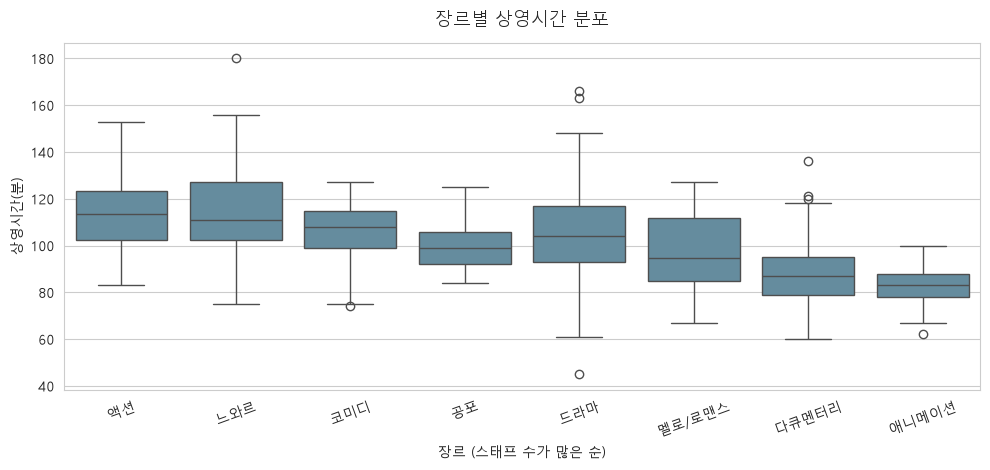

In [4]:
fig, ax = plt.subplots(figsize=(10, 4.8))
sns.boxplot(x='genre', y='time', data=sub, order=장르순, ax=ax, color='#5B8FA8')
ax.set_title('장르별 상영시간 분포', fontsize=13, pad=12)
ax.set_xlabel('장르 (스태프 수가 많은 순)')
ax.set_ylabel('상영시간(분)')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

액션·느와르가 110분대로 가장 길고, 다큐멘터리·애니메이션이 83~87분으로 가장 짧다.
**장르를 스태프 수 순으로 정렬했을 뿐인데 상영시간도 거의 같은 순서로 줄어든다.**

## 그래프 3. 장르별 스태프 수

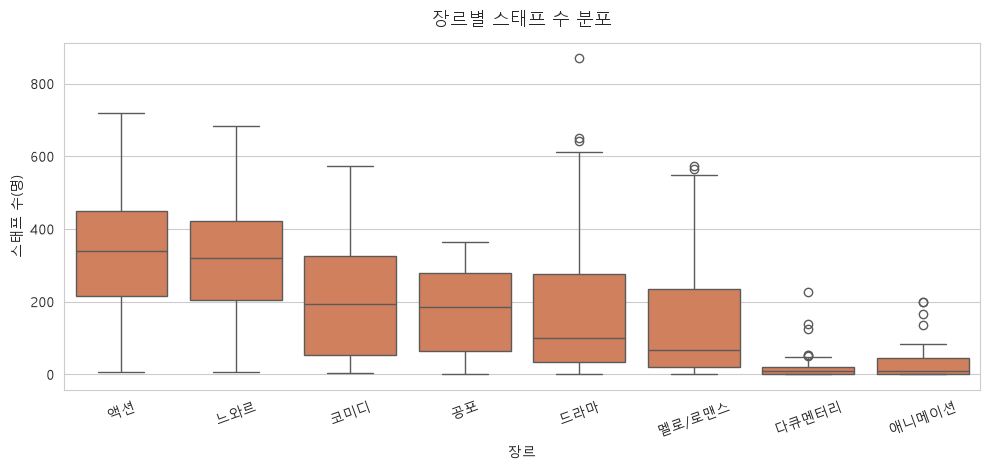

genre
액션        338
느와르       319
코미디       192
공포        185
드라마       101
멜로/로맨스     66
다큐멘터리       8
애니메이션       8
Name: num_staff, dtype: int64


In [5]:
fig, ax = plt.subplots(figsize=(10, 4.8))
sns.boxplot(x='genre', y='num_staff', data=sub, order=장르순, ax=ax, color='#E4794A')
ax.set_title('장르별 스태프 수 분포', fontsize=13, pad=12)
ax.set_xlabel('장르')
ax.set_ylabel('스태프 수(명)')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

print(sub.groupby('genre')['num_staff'].median().loc[장르순].astype(int))

액션 338명, 느와르 319명인 반면 **다큐멘터리와 애니메이션은 중앙값이 8명**이다.
40배 차이로, 같은 "영화"라는 이름으로 묶기 어려울 만큼 제작 방식이 다르다.

## 그래프 4. 상영시간 × 스태프 수 — 이 데이터에서 가장 강한 관계

상영시간 × 스태프 수   상관 : 0.623
스태프 수 × log관객수  상관 : 0.744


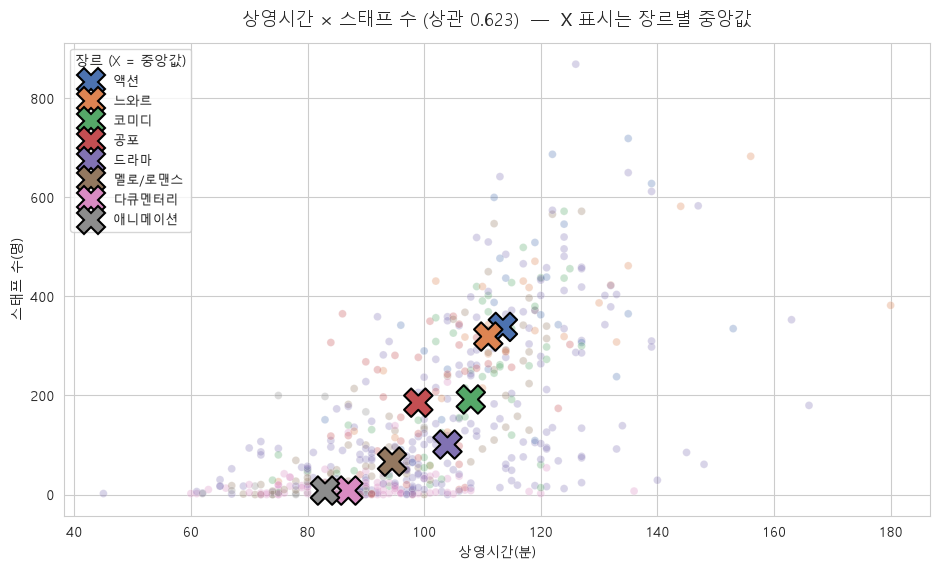

In [6]:
상관 = df[['time', 'num_staff']].corr().iloc[0, 1]
관객상관 = df[['num_staff', 'log관객수']].corr().iloc[0, 1]
print('상영시간 × 스태프 수   상관 : %.3f' % 상관)
print('스태프 수 × log관객수  상관 : %.3f' % 관객상관)

순서 = [g for g in 장르순 if g in sub['genre'].values]

# 장르별 중앙값 (개별 영화 위에 겹쳐 그려 장르 위치를 드러낸다)
중앙 = sub.groupby('genre')[['time', 'num_staff']].median().loc[순서].reset_index()

fig, ax = plt.subplots(figsize=(9.5, 5.8))
sns.scatterplot(x='time', y='num_staff', data=sub, hue='genre',
                hue_order=순서, alpha=0.3, s=32, ax=ax, legend=False)
sns.scatterplot(x='time', y='num_staff', data=중앙, hue='genre',
                hue_order=순서, s=420, marker='X', edgecolor='black',
                linewidth=1.5, ax=ax)
ax.set_title('상영시간 × 스태프 수 (상관 %.3f)  —  X 표시는 장르별 중앙값' % 상관,
             fontsize=13, pad=12)
ax.set_xlabel('상영시간(분)')
ax.set_ylabel('스태프 수(명)')
ax.legend(title='장르 (X = 중앙값)', fontsize=9, loc='upper left')
plt.tight_layout()
plt.show()

**상관 0.623으로, 스태프 수와 관객수의 상관(0.544)보다 높다.**
이 데이터에서 가장 강한 관계는 관객수와 무관한 곳에 있었던 것이다.

개별 영화는 넓게 흩어져 있지만, **X로 표시한 장르별 중앙값은 왼쪽 아래에서 오른쪽 위로
일렬로 늘어선다.** 다큐멘터리·애니메이션(짧고 적은 인원)에서 액션·느와르(길고 많은 인원)까지
이어지는 형태다.

상영시간과 제작 인원이 따로 정해지는 것이 아니라 "어떤 장르를 만드느냐"에 함께 묶여
결정된다고 볼 수 있다. 다만 같은 장르 안에서도 편차가 크므로, 장르가 전부를 설명하지는 않는다.

## 그래프 5. 장르 × 상영등급

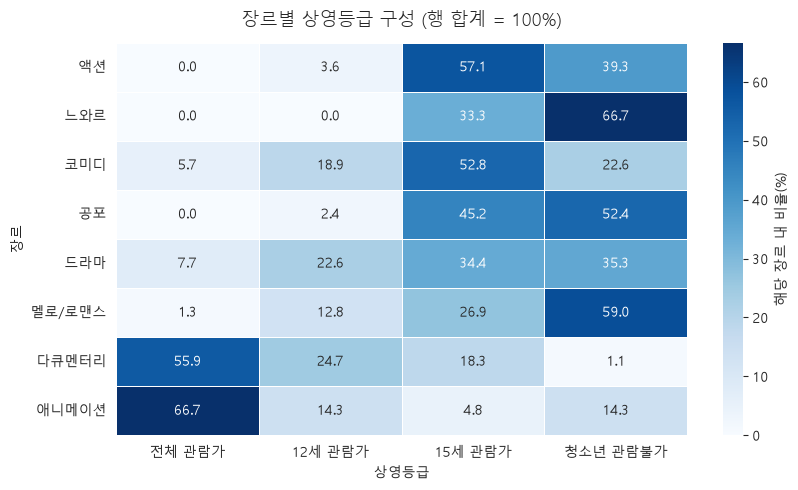

In [7]:
등급비율 = pd.crosstab(sub['genre'], sub['screening_rat'], normalize='index').loc[장르순] * 100
등급순 = ['전체 관람가', '12세 관람가', '15세 관람가', '청소년 관람불가']
등급비율 = 등급비율[등급순]

fig, ax = plt.subplots(figsize=(8.5, 5))
sns.heatmap(등급비율, annot=True, fmt='.1f', cmap='Blues', ax=ax,
            cbar_kws={'label': '해당 장르 내 비율(%)'}, linewidths=0.5)
ax.set_title('장르별 상영등급 구성 (행 합계 = 100%)', fontsize=13, pad=12)
ax.set_xlabel('상영등급')
ax.set_ylabel('장르')
plt.tight_layout()
plt.show()

느와르는 66.7%, 멜로/로맨스는 59.0%가 청소년 관람불가다.
애니메이션(66.7%)과 다큐멘터리(55.9%)는 전체 관람가에 몰려 있다.
장르가 관객층까지 사실상 결정하고 있다.

---
# 2부. 누가 어떤 영화를 맡는가

## 그래프 6. 감독 경력 × 제작 규모

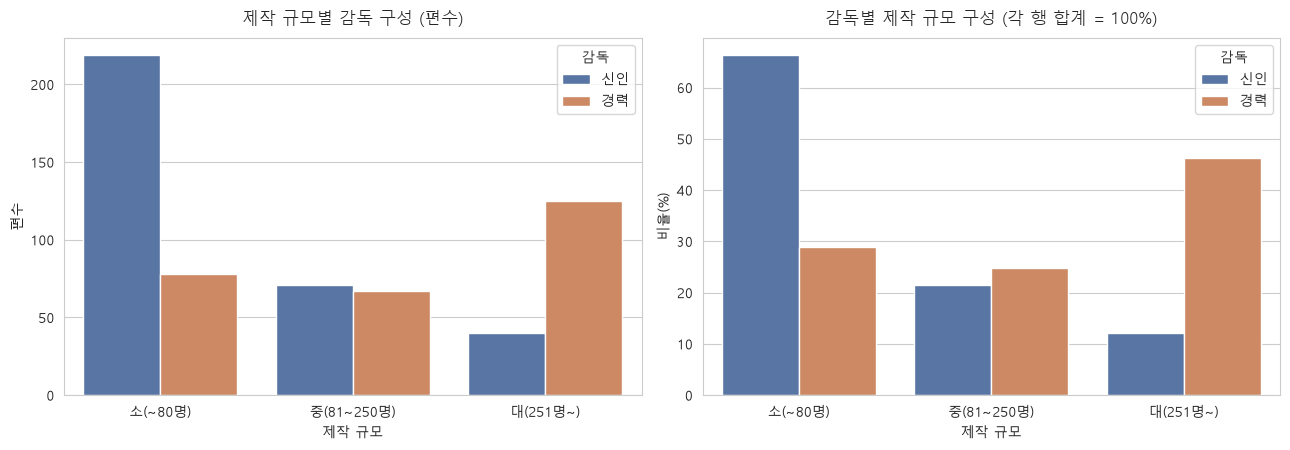

규모  소(~80명)  중(81~250명)  대(251명~)
감독                               
경력       78          67       125
신인      219          71        40


In [8]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))

sns.countplot(x='규모', hue='감독', data=df, ax=ax[0],
              hue_order=['신인', '경력'])
ax[0].set_title('제작 규모별 감독 구성 (편수)', fontsize=12, pad=10)
ax[0].set_xlabel('제작 규모')
ax[0].set_ylabel('편수')
ax[0].legend(title='감독')

경력별 = pd.crosstab(df['감독'], df['규모'], normalize='index').mul(100).reset_index()
녹임 = 경력별.melt(id_vars='감독', var_name='규모', value_name='비율')
sns.barplot(x='규모', y='비율', hue='감독', data=녹임, ax=ax[1],
            hue_order=['신인', '경력'])
ax[1].set_title('감독별 제작 규모 구성 (각 행 합계 = 100%)', fontsize=12, pad=10)
ax[1].set_xlabel('제작 규모')
ax[1].set_ylabel('비율(%)')
ax[1].legend(title='감독')

plt.tight_layout()
plt.show()

print(pd.crosstab(df['감독'], df['규모']))

**신인 감독 330편 중 대규모는 40편(12.1%)뿐이고, 경력 감독은 270편 중 125편(46.3%)이다.**

EDA에서 신인과 경력 감독의 관객수가 65배 차이 났던 것이 여기서 설명된다.
감독의 역량 차이라기보다 **애초에 맡는 영화의 규모가 다른 것**이다.
관객수를 거치지 않고도 직접 확인할 수 있다.

## 그래프 7. 장르별 신인 감독 비율

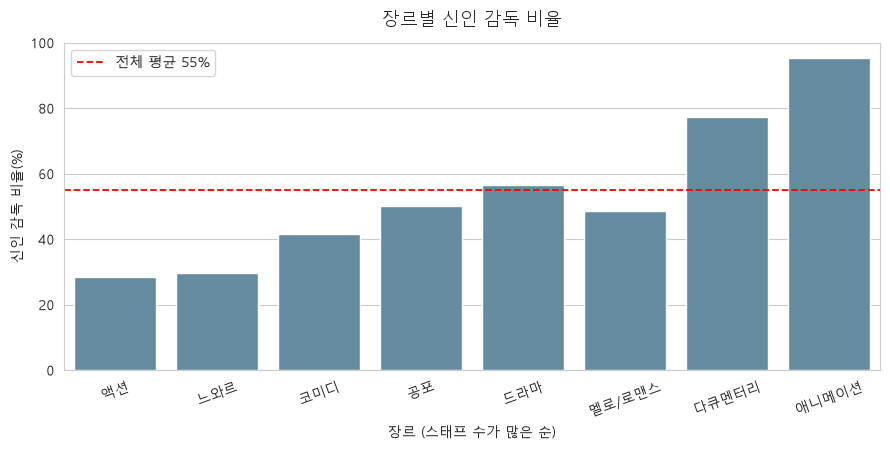

In [9]:
신인비율 = (sub.groupby('genre')['감독']
           .apply(lambda s: (s == '신인').mean() * 100)
           .loc[장르순].reset_index(name='신인비율'))

fig, ax = plt.subplots(figsize=(9, 4.6))
sns.barplot(x='genre', y='신인비율', data=신인비율, order=장르순,
            ax=ax, color='#5B8FA8')
ax.axhline(55.0, color='red', linestyle='--', linewidth=1.3,
           label='전체 평균 55%')
ax.set_title('장르별 신인 감독 비율', fontsize=13, pad=12)
ax.set_xlabel('장르 (스태프 수가 많은 순)')
ax.set_ylabel('신인 감독 비율(%)')
ax.legend()
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

**애니메이션은 95.2%, 다큐멘터리는 77.4%가 신인 감독 작품인 반면 액션은 28.6%다.**

그래프 1·3과 같은 순서로 정렬했는데 값이 정확히 반대 방향으로 간다.
제작 규모가 큰 장르일수록 경력 감독에게 맡겨진다는 뜻이다.

## 그래프 8. 배급사 × 장르

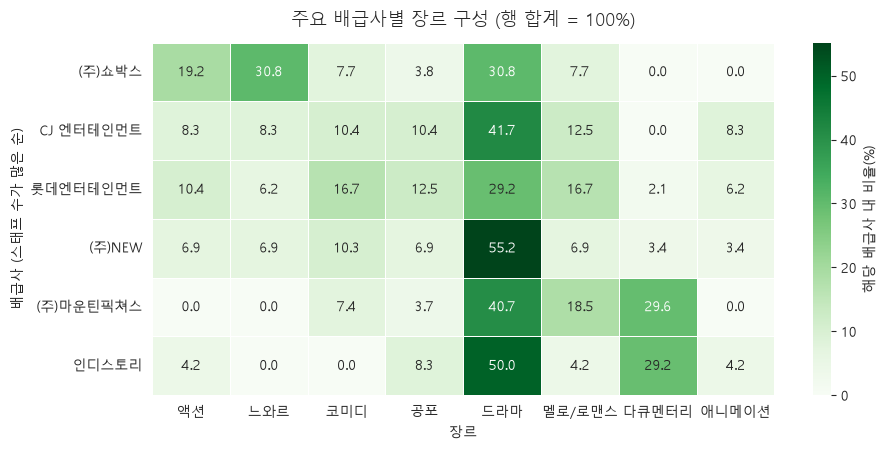

             편수   상영시간    스태프  신인비율
distributor                        
(주)쇼박스       26  127.0  349.5  15.4
CJ 엔터테인먼트    48  113.0  348.5  33.3
롯데엔터테인먼트     48  112.5  300.5  27.1
(주)NEW       29  114.0  300.0  37.9
(주)마운틴픽쳐스    27   94.0   37.0  70.4
인디스토리        24   92.0   31.0  87.5


In [10]:
상위배급 = df['distributor'].value_counts().head(6).index
배급 = df[df['distributor'].isin(상위배급) & df['genre'].isin(주요장르)]

배급비율 = pd.crosstab(배급['distributor'], 배급['genre'], normalize='index') * 100
배급비율 = 배급비율[[g for g in 장르순 if g in 배급비율.columns]]
배급비율 = 배급비율.loc[배급.groupby('distributor')['num_staff'].median()
                     .sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(9.5, 4.6))
sns.heatmap(배급비율, annot=True, fmt='.1f', cmap='Greens', ax=ax,
            cbar_kws={'label': '해당 배급사 내 비율(%)'}, linewidths=0.5)
ax.set_title('주요 배급사별 장르 구성 (행 합계 = 100%)', fontsize=13, pad=12)
ax.set_xlabel('장르')
ax.set_ylabel('배급사 (스태프 수가 많은 순)')
plt.tight_layout()
plt.show()

print(배급.groupby('distributor').agg(
    편수=('title', 'size'), 상영시간=('time', 'median'),
    스태프=('num_staff', 'median'),
    신인비율=('감독', lambda s: round((s == '신인').mean() * 100, 1))
).sort_values('스태프', ascending=False))

배급사마다 미는 장르가 뚜렷하게 다르다.
**쇼박스는 느와르가 30.8%** 로 유독 높고, **인디스토리는 다큐멘터리가 26.9%** 다.

제작 방식도 갈린다. 쇼박스는 상영시간 127분·스태프 349.5명·신인 감독 15.4%인 반면,
인디스토리는 92분·30.5명·**80.8%** 다. 같은 영화 산업 안에 성격이 다른 두 흐름이 있다.

---
# 3부. 언제 어떤 영화가 나오는가

## 그래프 9. 월별 대규모 영화 비율

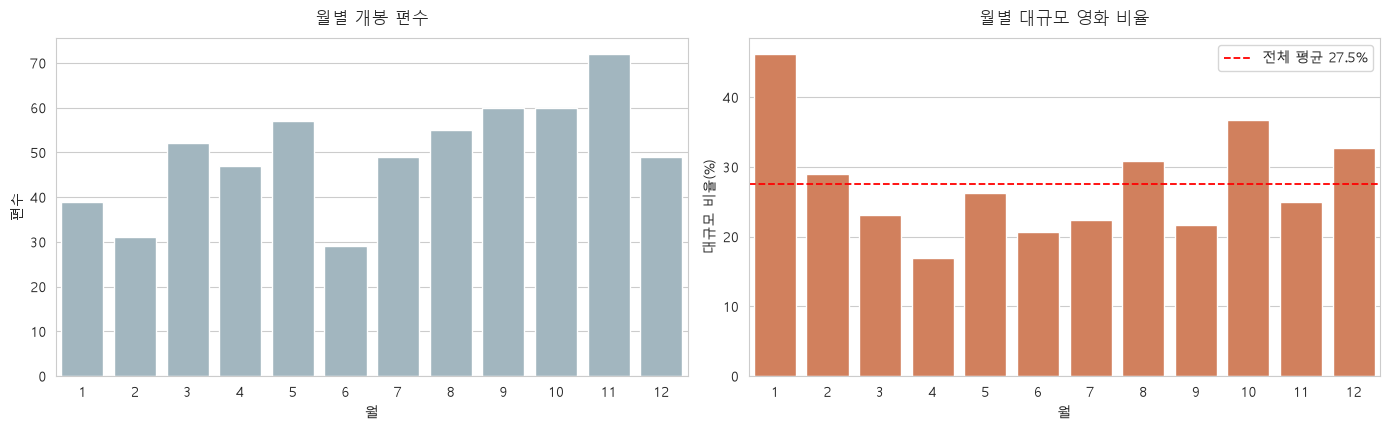

 월  전체편수  대규모비율
 1    39   46.2
 2    31   29.0
 3    52   23.1
 4    47   17.0
 5    57   26.3
 6    29   20.7
 7    49   22.4
 8    55   30.9
 9    60   21.7
10    60   36.7
11    72   25.0
12    49   32.7


In [11]:
월별 = df.groupby('월').agg(
    전체편수=('title', 'size'),
    대규모비율=('규모', lambda s: (s == '대(251명~)').mean() * 100)
).round(1).reset_index()

fig, ax = plt.subplots(1, 2, figsize=(14, 4.4))

sns.barplot(x='월', y='전체편수', data=월별, ax=ax[0], color='#9DB8C4')
ax[0].set_title('월별 개봉 편수', fontsize=12, pad=10)
ax[0].set_ylabel('편수')

sns.barplot(x='월', y='대규모비율', data=월별, ax=ax[1], color='#E4794A')
ax[1].axhline(df['규모'].eq('대(251명~)').mean() * 100, color='red',
              linestyle='--', linewidth=1.3, label='전체 평균 27.5%')
ax[1].set_title('월별 대규모 영화 비율', fontsize=12, pad=10)
ax[1].set_ylabel('대규모 비율(%)')
ax[1].legend()

plt.tight_layout()
plt.show()

print(월별.to_string(index=False))

개봉 편수는 11월(72편)·9월·10월(각 60편)에 많지만, **대규모 영화 비율은 1월이 46.2%로 가장 높다.**
설 연휴가 있는 1월과 10·12월에 큰 영화가 몰리고, 4월(17.0%)에 가장 적다.

**편수가 많은 달과 큰 영화가 개봉하는 달이 다르다**는 점이 눈에 띈다.

## 그래프 10. 연도별 제작 규모 구성의 변화

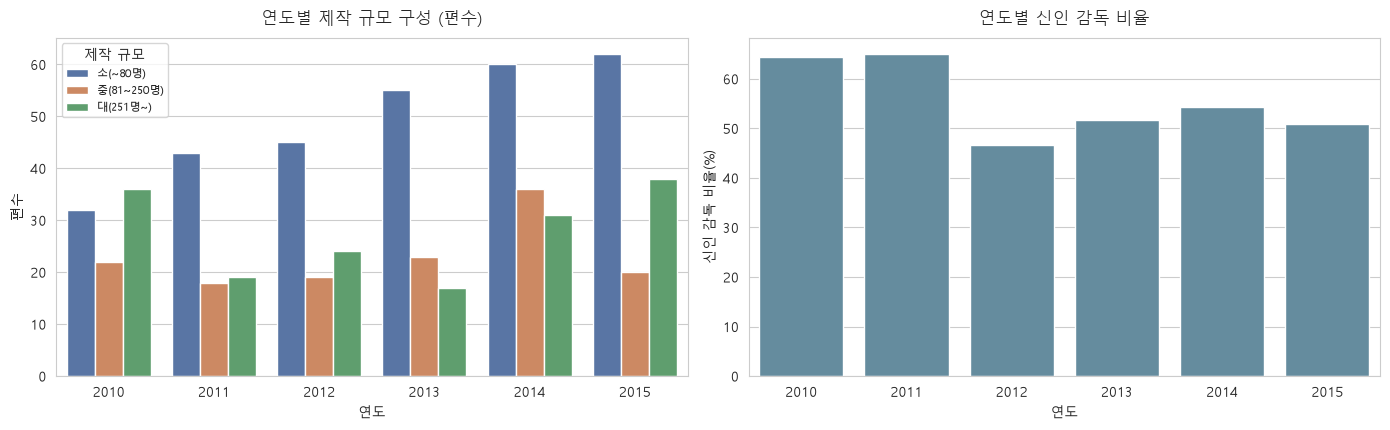

       편수   상영시간    스태프  신인비율
연도                           
2010   90  104.5  150.5  64.4
2011   80  102.5   64.5  65.0
2012   88  100.0   70.0  46.6
2013   95   98.0   59.0  51.6
2014  127   99.0   96.0  54.3
2015  120   99.5   73.0  50.8


In [12]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4.4))

sns.countplot(x='연도', hue='규모', data=df, ax=ax[0])
ax[0].set_title('연도별 제작 규모 구성 (편수)', fontsize=12, pad=10)
ax[0].set_ylabel('편수')
ax[0].legend(title='제작 규모', fontsize=8)

연도지표 = df.groupby('연도').agg(
    신인비율=('감독', lambda s: (s == '신인').mean() * 100)).reset_index()
sns.barplot(x='연도', y='신인비율', data=연도지표, ax=ax[1], color='#5B8FA8')
ax[1].set_title('연도별 신인 감독 비율', fontsize=12, pad=10)
ax[1].set_ylabel('신인 감독 비율(%)')

plt.tight_layout()
plt.show()

print(df.groupby('연도').agg(
    편수=('title', 'size'), 상영시간=('time', 'median'),
    스태프=('num_staff', 'median'),
    신인비율=('감독', lambda s: round((s == '신인').mean() * 100, 1))))

개봉 편수는 2010년 90편에서 2014년 127편으로 늘었고, 늘어난 몫은 주로 소규모 영화다.
**신인 감독 비율은 2010~2011년 64~65%에서 2015년 50.8%로 낮아졌다.**

---
# 4부. 그래서 결과는 어땠는가

앞의 세 부에서 관객수를 쓰지 않고 제작 구조를 살펴보았다.
이제 그 구조가 결과와 어떻게 연결되는지 확인한다.

## 그래프 11. 제작 규모 × 감독 경력 × 관객수

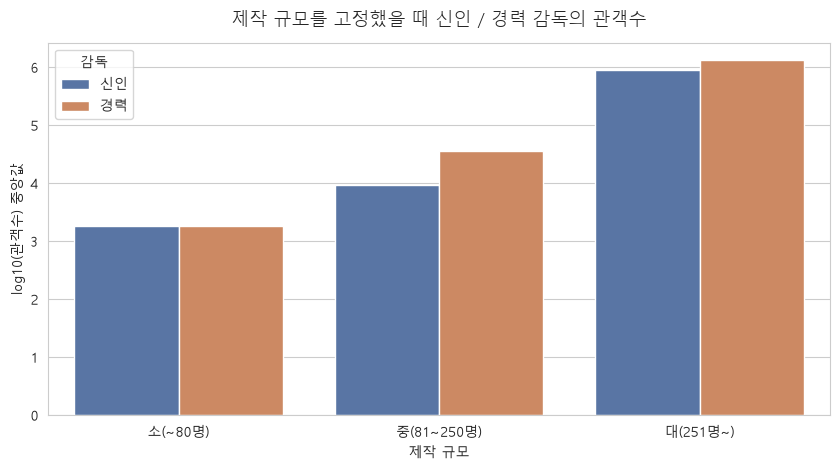

[관객수 중앙값]
규모  소(~80명)  중(81~250명)   대(251명~)
감독                                
경력   1878.0     35567.0  1310895.0
신인   1806.0      9323.0   885336.0


In [13]:
fig, ax = plt.subplots(figsize=(8.5, 4.8))
sns.barplot(x='규모', y='log관객수', hue='감독', data=df,
            estimator=np.median, errorbar=None, ax=ax,
            hue_order=['신인', '경력'])
ax.set_title('제작 규모를 고정했을 때 신인 / 경력 감독의 관객수', fontsize=13, pad=12)
ax.set_xlabel('제작 규모')
ax.set_ylabel('log10(관객수) 중앙값')
ax.legend(title='감독')
plt.tight_layout()
plt.show()

print('[관객수 중앙값]')
print(df.pivot_table(index='감독', columns='규모', values='box_off_num',
                     aggfunc='median', observed=True).round(0))

전체로 보면 신인 3,402명 vs 경력 222,258명으로 **65배** 차이지만,
제작 규모를 맞추면 소규모에서 1,806명 vs 1,878명으로 **거의 같아진다.**

그래프 6에서 확인한 "신인에게는 큰 영화가 맡겨지지 않는다"가 관객수 차이의 원인이었다.
**제작 규모가 감독 경력과 관객수 사이의 교란 변수**인 것이다.

## 그래프 12. 장르 × 제작 규모별 관객수

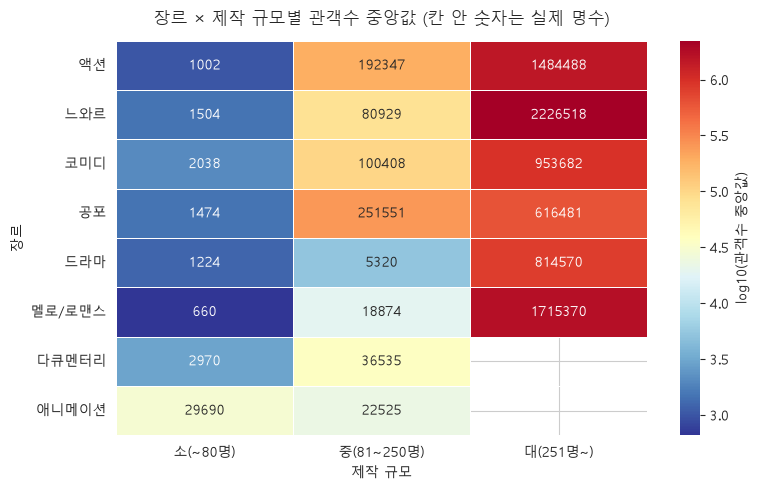

In [14]:
관객표 = sub.pivot_table(index='genre', columns='규모', values='box_off_num',
                       aggfunc='median', observed=True).loc[장르순]

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(np.log10(관객표), annot=관객표.round(0), fmt='.0f',
            cmap='RdYlBu_r', ax=ax, linewidths=0.5,
            cbar_kws={'label': 'log10(관객수 중앙값)'})
ax.set_title('장르 × 제작 규모별 관객수 중앙값 (칸 안 숫자는 실제 명수)',
             fontsize=12, pad=12)
ax.set_xlabel('제작 규모')
ax.set_ylabel('장르')
plt.tight_layout()
plt.show()

같은 제작 규모 안에서 장르별 차이를 보면, **중간 규모에서 격차가 가장 크다.**
공포는 251,551명인데 드라마는 5,320명으로 약 47배 차이가 난다.

반면 대규모에서는 장르 간 차이가 3~4배 수준으로 줄어든다.
큰 영화는 장르와 무관하게 일정 규모의 관객을 확보하고,
작은 영화는 무엇을 만들든 한계가 있으며, **중간 규모에서만 장르 선택이 결정적**이라고 볼 수 있다.

(빈 칸은 해당 조합의 영화가 없다는 뜻으로, 다큐멘터리·애니메이션의 대규모가 이에 해당한다.)

## 그래프 13. 변수 간 상관관계 종합

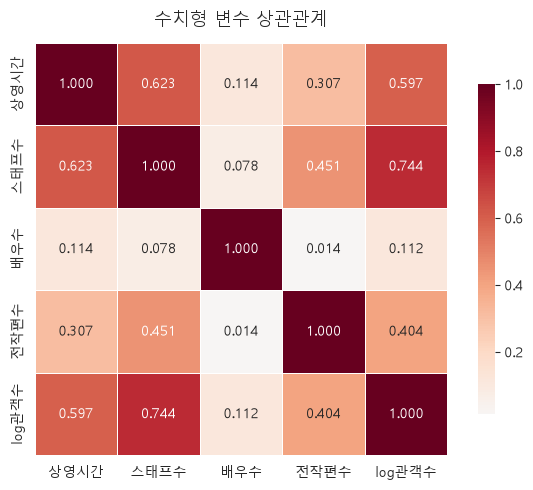

In [15]:
수치 = df[['time', 'num_staff', 'num_actor', 'dir_prev_num', 'log관객수']].copy()
수치.columns = ['상영시간', '스태프수', '배우수', '전작편수', 'log관객수']

fig, ax = plt.subplots(figsize=(6.5, 5))
sns.heatmap(수치.corr(), annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            square=True, ax=ax, linewidths=0.5, cbar_kws={'shrink': 0.8})
ax.set_title('수치형 변수 상관관계', fontsize=13, pad=12)
plt.tight_layout()
plt.show()

가장 강한 관계는 **상영시간 × 스태프 수(0.623)** 로, 관객수가 포함되지 않은 쌍이다.
스태프 수 × 관객수(0.544)보다 높다.

한편 **배우 수는 어느 변수와도 상관이 0.1 안팎**으로, 이 데이터에서 사실상 고립되어 있다.
배우를 많이 기용한다고 제작 규모가 크지도, 관객이 늘지도 않는다.

---
# 정리

### 확인한 것

1. **장르가 제작 방식을 정한다.** 장르를 스태프 수 순으로 정렬하면 상영시간·대규모 비율·
   신인 감독 비율이 모두 같은 순서로 움직인다. 액션·느와르는 길고 크게, 다큐멘터리·애니메이션은
   짧고 작게 만들어지며, 후자는 대규모가 한 편도 없다.

2. **이 데이터에서 가장 강한 관계는 관객수와 무관하다.** 상영시간 × 스태프 수가 0.623으로
   스태프 수 × 관객수(0.544)보다 높다.

3. **신인 감독에게는 큰 영화가 맡겨지지 않는다.** 신인의 12.1%만 대규모를 맡고 경력은 46.3%다.
   신인/경력의 관객수 65배 차이는 여기서 비롯된 것으로, 제작 규모를 고정하면 차이가 사라진다.

4. **배급사마다 미는 장르와 제작 방식이 다르다.** 쇼박스는 느와르, 인디스토리는 다큐멘터리에
   치우쳐 있고 신인 감독 비율은 15.4% 대 80.8%다.

5. **큰 영화는 1월에 몰린다.** 개봉 편수가 가장 많은 달은 11월이지만 대규모 비율은 1월이 46.2%로 최고다.

6. **장르는 중간 규모에서만 결정적이다.** 중간 규모에서 장르 간 관객수 격차가 47배인 반면
   대규모에서는 3~4배로 줄어든다.

### 한계

- 600편은 같은 기간 개봉작 전체가 아니라 일부이며, 표본 추출 방식이 명시되어 있지 않다.
- 서스펜스(2편)·뮤지컬(5편)·SF(13편)는 편수가 적어 분석에서 제외했다.
- 스태프 수를 제작비의 대리 지표로 사용했으나 실제 예산 정보는 데이터에 없다.
- 모든 관계는 상관이며, 인과로 해석할 수 없다.